In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

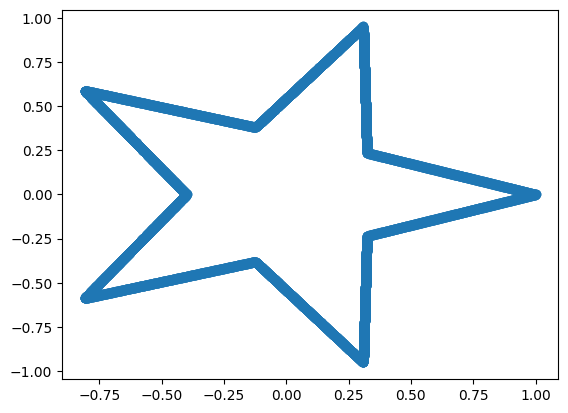

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    beta_min = 0.1
    beta_max = 20.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000
    schedule = 'linear'
    weight = None
    min_snr_gamma = 5.0
    cosine_s = 0.008

In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [6]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [7]:
def beta_t(t, config):
    if config.schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)

    else:
        s = config.cosine_s
        x = (t + s) / (1.0 + s) * (math.pi / 2.0)
        beta = (math.pi / (1.0 + s)) * torch.tan(x)

        x_max = math.pi / 2.0
        beta_max_t = (math.pi / (1.0 + s)) * math.tan(x_max)
        beta = config.beta_min + (beta / beta_max_t) * (config.beta_max - config.beta_min)
        return beta

def alpha_t(t, config):
    if config.schedule == 'linear':
        integral = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2
        return torch.exp(-0.5 * integral)

    else:
        s = config.cosine_s
        x = (t + s) / (1.0 + s) * (math.pi / 2.0)
        return torch.cos(x)

def sigma_t_vp(t, config):
    a = alpha_t(t, config)
    return torch.sqrt(1.0 - a**2 + 1e-8)

def g_t_vp(t, config):
    return torch.sqrt(beta_t(t, config))

In [8]:
class VPTrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.loss_history = []

    def get_weight(self, alpha, sigma):
        if self.config.weight is None:
            return torch.ones_like(alpha)

        elif self.config.weight == 'inv_sigma':
            return 1.0 / (sigma**2 + 1e-8)

        elif self.config.weight == 'snr':
            return (alpha**2) / (sigma**2 + 1e-8)

        elif self.config.weight == 'min_snr':
            snr = (alpha**2) / (sigma**2 + 1e-8)
            gamma = self.config.min_snr_gamma

            return torch.minimum(snr, torch.ones_like(snr) * gamma)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t_vp(t, self.config)
            alpha = alpha_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)
            weight = self.get_weight(alpha, sigma)

            mse = F.mse_loss(pred_z, z, reduction='none').mean(dim=1, keepdim=True)
            loss = (weight * mse).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            self.loss_history.append(loss)
            if n % 100 == 0:
                print(f'Loss = {loss}')

In [9]:
config = Config()
trainer_ve = VETrainer(config)

In [10]:
trainer_ve.run()

Loss: 0.9014400868415833
Loss: 0.6458651769638062
Loss: 0.6371836813926697
Loss: 0.6392756602287293
Loss: 0.5943736898422242
Loss: 0.6114179936408997
Loss: 0.5850275748252869
Loss: 0.6007043099403382
Loss: 0.5789610238075257
Loss: 0.5645156309127808
Loss: 0.5821761503219605
Loss: 0.5641095275878907
Loss: 0.5410545196056366
Loss: 0.5499344736099243
Loss: 0.5612875771522522
Loss: 0.5600761043548584
Loss: 0.5501752571105957
Loss: 0.5610708826065064
Loss: 0.5568969012260437
Loss: 0.5374353733062744


In [11]:
def sample_ve(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [12]:
def sample_vp(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            sigma = sigma_t_vp(t_tensor, config)
            g = g_t_vp(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / (sigma + 1e-8)

            diffusion = g * torch.randn_like(x) * math.sqrt(dt)
            drift = (0.5 * beta * x + (g**2) * score) * dt

            x = x + drift + diffusion

        return x.cpu().numpy()

In [13]:
samples_ve = sample_ve(trainer_ve.model, trainer_ve.config, 1000)

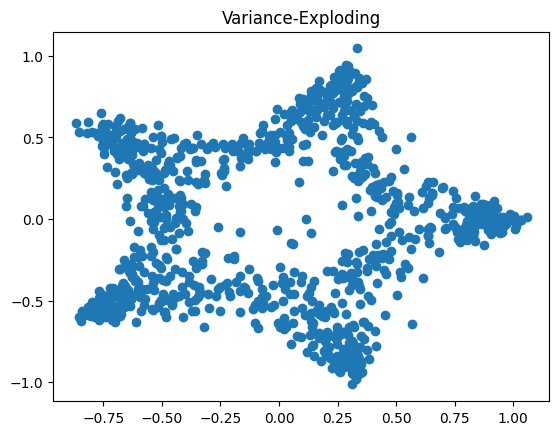

In [14]:
plt.scatter(samples_ve[:, 0], samples_ve[:, 1])
plt.title("Variance-Exploding")
plt.show()

In [15]:
trainer_vp = VPTrainer(config)
trainer_vp.run()

Loss = 0.8788402575492859
Loss = 0.1796009489774704
Loss = 0.17080317616462706
Loss = 0.17600769896507262
Loss = 0.1595199145078659
Loss = 0.16398500978946687
Loss = 0.17823100423812865
Loss = 0.1529468995809555
Loss = 0.15478993730545043
Loss = 0.15836731462478637
Loss = 0.16096779031753541
Loss = 0.1604970801115036
Loss = 0.15913703591823578
Loss = 0.1534703536272049
Loss = 0.16172372176647187
Loss = 0.16116752314567567
Loss = 0.1529091922044754
Loss = 0.1513296236515045
Loss = 0.15899514805078507
Loss = 0.1494607637166977


In [16]:
samples_vp = sample_vp(trainer_vp.model, trainer_vp.config, 1000)

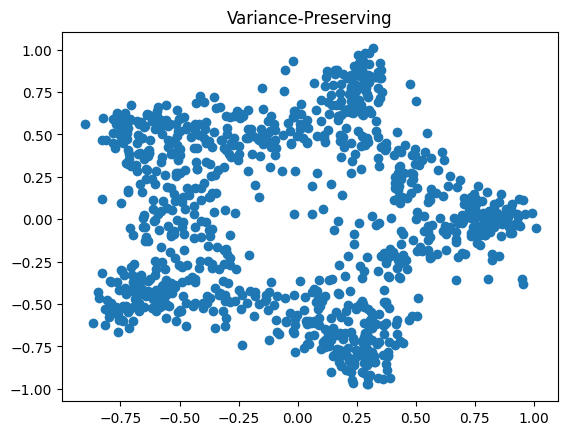

In [17]:
plt.scatter(samples_vp[:, 0], samples_vp[:, 1])
plt.title("Variance-Preserving")
plt.show()

 ### Обе модели (VE и VP) успешно восстанавливают распределение данных. Звезда с Variance-Exploding выглядит более приближенной к изначальной: более чёткие линии и меньше шума.

In [18]:
config_cos = Config()
config_cos.schedule = 'cosine'

trainer_cos = VPTrainer(config_cos)
trainer_cos.run()

samples_cos = sample_vp(trainer_cos.model, trainer_cos.config, 1000)

Loss = 0.9095193633079529
Loss = 0.3319568160533905
Loss = 0.31707787761688233
Loss = 0.3160957638263702
Loss = 0.305043909740448
Loss = 0.2877513792037964
Loss = 0.2954201160430908
Loss = 0.3011429907798767
Loss = 0.28998101143836974
Loss = 0.2901387573719025
Loss = 0.29782039041519165
Loss = 0.2946386957168579
Loss = 0.2812957033157349
Loss = 0.2807311951160431
Loss = 0.2859609519958496
Loss = 0.29784165315628053
Loss = 0.29475948705673216
Loss = 0.27823231387138364
Loss = 0.2787412530899048
Loss = 0.29561829156875613


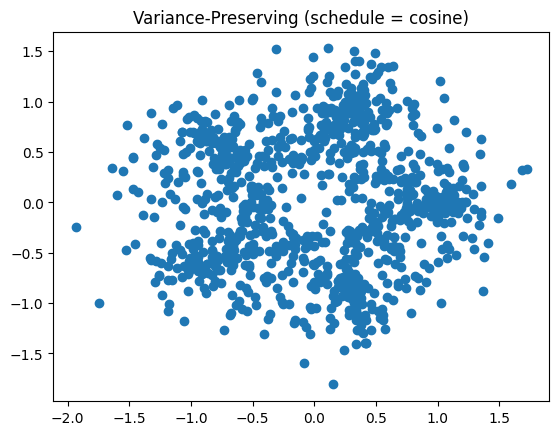

In [19]:
plt.scatter(samples_cos[:, 0], samples_cos[:, 1])
plt.title("Variance-Preserving (schedule = cosine)")
plt.show()

### Сгенерированные сэмплы с линейным расписанием выглядят более чёткими. С косинусным расписанием шум добавляется медленнее, модель сохраняет высокое SNR и более осторожно предсказывает шум на промежуточных шагах.
### Возможно, для косинусного расписания количество шагов сэмплирования = 1000 недостаточно.

In [20]:
weight_types = [None, 'inv_sigma', 'snr', 'min_snr']
results_weighted = {}

for w in weight_types:
    weight_name = w if w else 'None'
    print(f"Weight = {weight_name}")

    config = Config()
    config.weight = w

    trainer = VPTrainer(config)
    trainer.run()

    samples = sample_vp(trainer.model, config, num_samples=1000)
    results_weighted[weight_name] = {
        'samples': samples,
        'loss_history': trainer.loss_history,
        'final_loss': trainer.loss_history[-1]
    }

Weight = None
Loss = 0.8837663681030273
Loss = 0.1789092211008072
Loss = 0.1780546138525009
Loss = 0.17482962772846222
Loss = 0.170716406083107
Loss = 0.16796567542552948
Loss = 0.16324370555877685
Loss = 0.15826336677074432
Loss = 0.16329802916049957
Loss = 0.15971248652935027
Loss = 0.1637217148065567
Loss = 0.16515028202533721
Loss = 0.15617701354026794
Loss = 0.155937011218071
Loss = 0.15199536895751953
Loss = 0.16378441882133485
Loss = 0.15466894512176513
Loss = 0.1633245241880417
Loss = 0.15039487850666047
Loss = 0.15433217720985412
Weight = inv_sigma
Loss = 67.16642114562988
Loss = 91.67400769042969
Loss = 1773.2862915912629
Loss = 107.23731052856445
Loss = 45.98990059814453
Loss = 62.018034768676756
Loss = 70.01144108276367
Loss = 55.81707097473144
Loss = 31.747323574829103
Loss = 45.60298262023926
Loss = 90.07637680664062
Loss = 69.523559375
Loss = 1399.1571691711426
Loss = 82.4196902923584
Loss = 50.403893518066404
Loss = 73.13635514984131
Loss = 109.26404241027832
Loss = 33.

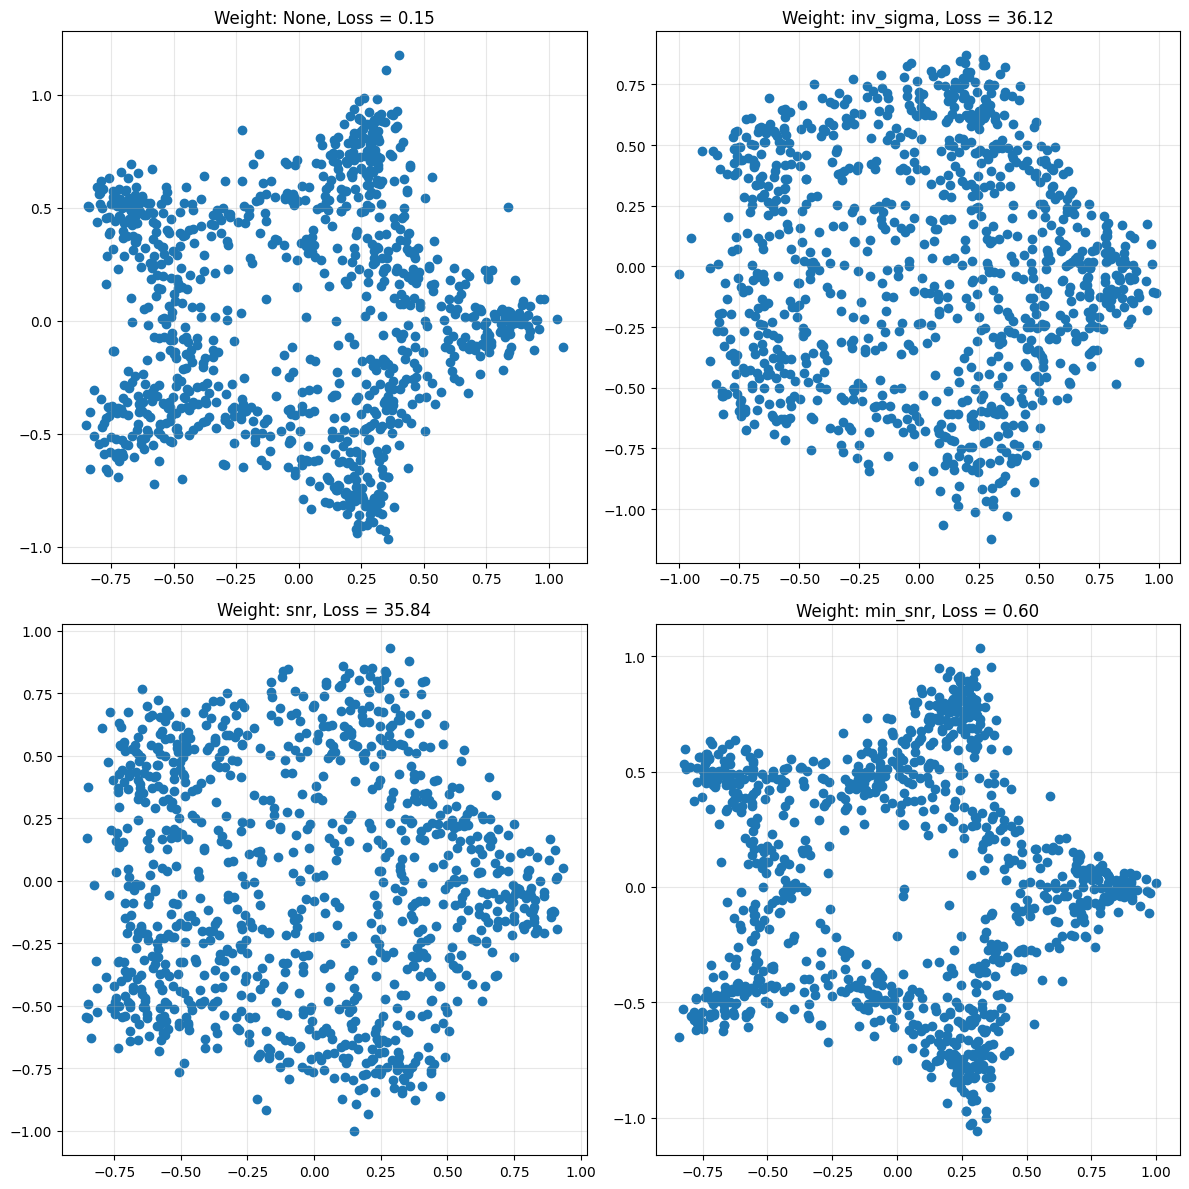

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (w, data) in zip(axes.flat, results_weighted.items()):
    samples = data['samples']
    loss = data['final_loss']

    ax.scatter(samples[:, 0], samples[:, 1])
    ax.set_title(f'Weight: {w}, Loss = {loss:.2f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

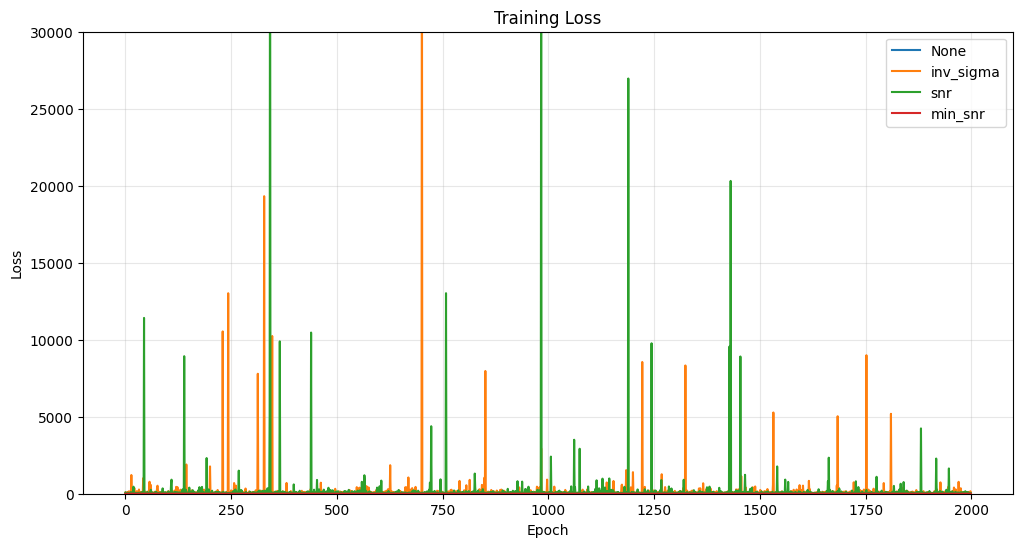

In [24]:
plt.figure(figsize=(12, 6))

for w, data in results_weighted.items():
    plt.plot(data['loss_history'], label=w)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.ylim(0, 30000)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

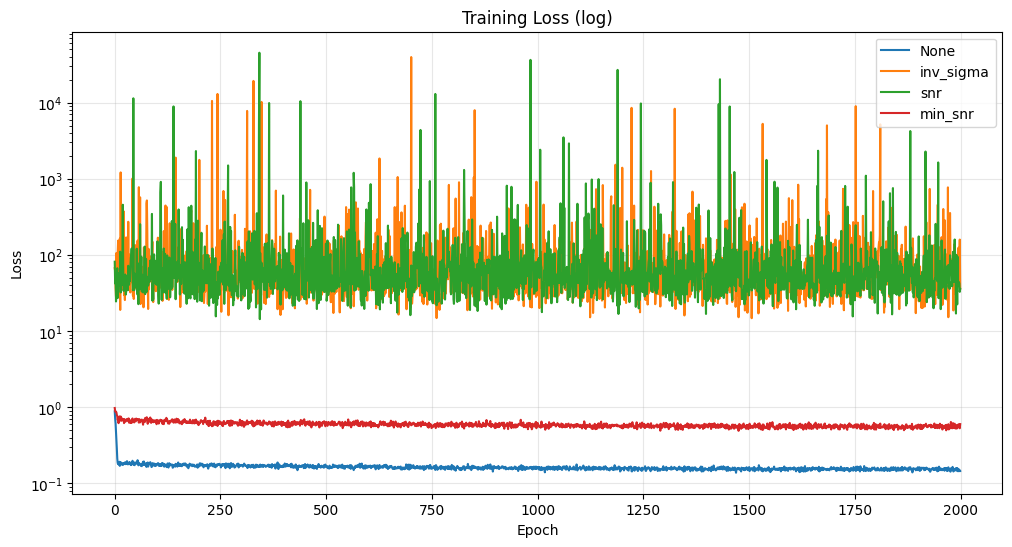

In [29]:
plt.figure(figsize=(12, 6))

for w, data in results_weighted.items():
    history = data['loss_history']
    plt.semilogy(history, label=w)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (log)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Без взешивания лосс быстрее сходится к низким значениям. С min_snr значения лосса немного выше, чем без взвешивания, но качество сэмплоа наилучшее среди всех стратегий, форма звезды чётче и ровнее.

### inv_sigma и snr приводят к слишком большим и нестабильным значениям лосса, так как они принимают самые большие значения именно на тех шагах, где задача предсказания шума является самой сложной. На графике видно, как значения лосса "взрываются" до огромных значений. Такие стратегии взвешивания лучше работают на более сложных изображениях, где важны детали, текстуры, поэтому структура простой геометрической фигуры разрушается.